  Age (years)  Gender  BMI (kg/m^2) Blood_Pressure (mmHg)  \
0          34    male          27.9                94/119   
1          72  Female          25.7               163/109   
2          29  Others           NaN               161/108   
3          18  female          27.9               115/112   
4          34    male          25.5               169/117   

   Cholesterol (mg/dL)  Glucose (mg/dL)  Heart_Rate (bpm) Smoking  \
0                277.0            104.0             111.0     NaN   
1                264.0            122.0              81.0     NaN   
2                248.0            103.0              90.0      no   
3                191.0            127.0              64.0       N   
4                152.0              NaN              79.0     Yes   

   Alcohol_Intake (units/week)  Physical_Activity (hours/week) Family_History  \
0                          4.0                             5.8             no   
1                          4.0                          

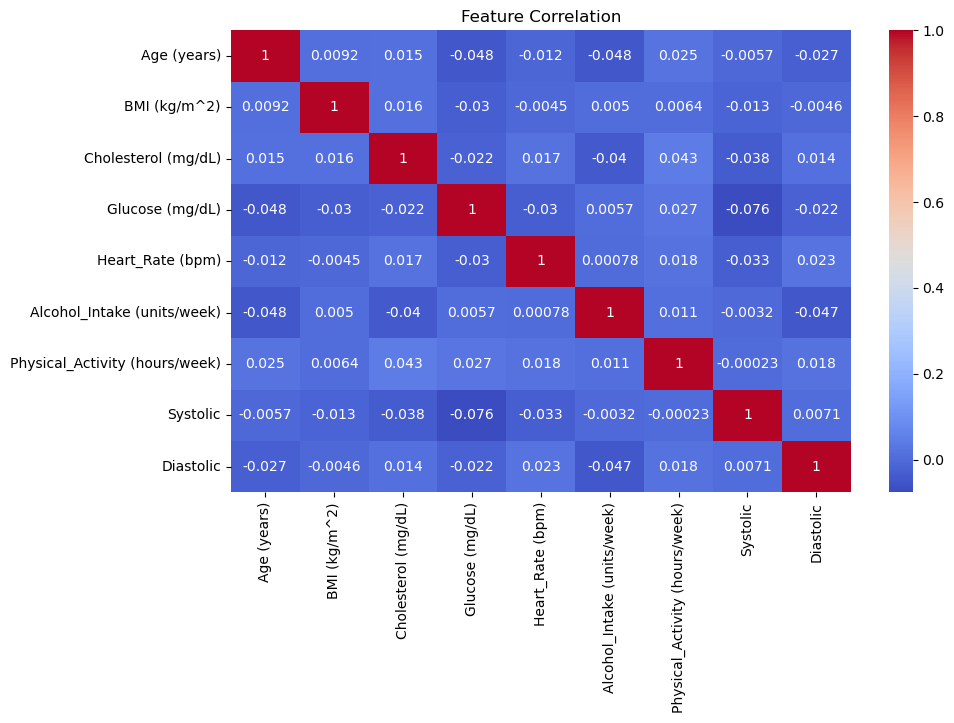

In [5]:
# -------------------- PHASE 1: EDA + DATA PREPROCESSING --------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("Improved_DataSet.csv")

# ---------------- BASIC INFO ----------------
print(df.head())
print(df.info())
print(df.isnull().sum())

# ---------------- CLEANING ----------------

# Handle Blood Pressure column
if "Blood_Pressure (mmHg)" in df.columns:
    bp = df["Blood_Pressure (mmHg)"].astype(str).str.split("/", expand=True)
    df["Systolic"] = pd.to_numeric(bp[0], errors='coerce')
    df["Diastolic"] = pd.to_numeric(bp[1], errors='coerce')
    df.drop("Blood_Pressure (mmHg)", axis=1, inplace=True)

# Lowercase all text columns
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.lower()

# Encode categorical columns (if present)
if "gender" in df.columns:
    df["gender"] = df["gender"].map({"male":1, "m":1, "female":0, "f":0})

if "smoking" in df.columns:
    df["smoking"] = df["smoking"].map({"yes":1, "y":1, "no":0, "n":0})

if "disease_risk" in df.columns:
    df["disease_risk"] = df["disease_risk"].map({
        "low":0,
        "medium":0,
        "high":1
    })

# Convert text numbers to numeric
word_to_num = {
    "zero":0, "one":1, "two":2, "three":3, "four":4,
    "five":5, "six":6, "seven":7, "eight":8, "nine":9,
    "ten":10, "twenty":20, "thirty":30, "forty":40, "fifty":50
}
df.replace(word_to_num, inplace=True)

# Convert all possible values to numeric
df_numeric = df.apply(pd.to_numeric, errors='coerce')

# Remove useless columns (all NaN)
df_numeric = df_numeric.dropna(axis=1, how='all')

# Remove constant columns
df_numeric = df_numeric.loc[:, df_numeric.nunique() > 1]

# Drop remaining NaN rows
df_numeric = df_numeric.dropna()

# ---------------- EDA ----------------

plt.figure(figsize=(10,6))
sns.heatmap(df_numeric.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()